# PaySim Anomaly Detection

Models: **XGBoost · Isolation Forest · Autoencoder · Ensemble**

In [1]:
# Install extra dependency if needed (Colab)
# !pip install xgboost -q

import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

import xgboost as xgb

RANDOM_STATE = 42
DATASET_NAME = "PaySim"

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

## 1. Load Data

In [2]:
df = pd.read_csv("paysim.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
print("Shape:", df.shape)
print(df.info())
print("Missing values:", df.isnull().sum().sum())
print(df["isFraud"].value_counts())

Shape: (3573818, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3573818 entries, 0 to 3573817
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 299.9+ MB
None
Missing values: 0
isFraud
0    3570889
1       2929
Name: count, dtype: int64


## 2. Preprocessing

In [4]:
# Drop unnecessary columns
if "isFlaggedFraud" in df.columns:
    df = df.drop(columns=["isFlaggedFraud"])

drop_cols = [col for col in ["nameOrig", "nameDest"] if col in df.columns]
if drop_cols:
    df = df.drop(columns=drop_cols)

# Encode transaction type
df["type"] = df["type"].astype("category").cat.codes

# Rename target column
df = df.rename(columns={"isFraud": "Class"})
df.head()
df = df.dropna()                    # удаляет строки с NaN
df["Class"] = df["Class"].astype(int)  # гарантирует int, не float

## 3. Dataset Summary

In [5]:
total_samples  = len(df)
fraud_samples  = int(df["Class"].sum())
normal_samples = total_samples - fraud_samples
fraud_ratio    = fraud_samples / total_samples

dataset_summary = pd.DataFrame([{
    "Dataset":           DATASET_NAME,
    "Total Samples":     total_samples,
    "Normal Samples":    normal_samples,
    "Fraud Samples":     fraud_samples,
    "Fraud Ratio":       fraud_ratio,
    "Number of Features": df.shape[1] - 1
}])
print(dataset_summary)
dataset_summary.to_csv("paysim_dataset_summary.csv", index=False)

  Dataset  Total Samples  Normal Samples  Fraud Samples  Fraud Ratio  \
0  PaySim        3573818         3570889           2929      0.00082   

   Number of Features  
0                   7  


## 4. Split Data

In [6]:
X = df.drop(columns=["Class"])
y = df["Class"]

contamination = max(y.mean(), 1e-4)
print("Contamination:", contamination)

# ── Supervised split (XGBoost) ──────────────────────────────────────────────
X_train_sup, X_test_sup, y_train_sup, y_test_sup = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# ── Unsupervised split: train on normal only ────────────────────────────────
X_normal = X[y == 0]
X_fraud  = X[y == 1]

X_train_normal, X_test_normal = train_test_split(
    X_normal, test_size=0.2, random_state=RANDOM_STATE
)

# Shared unsupervised test set = normal_test + all fraud
X_test_unsup = pd.concat([X_test_normal, X_fraud], axis=0)
y_test_unsup = np.concatenate([
    np.zeros(len(X_test_normal)),
    np.ones(len(X_fraud))
])

print("XGBoost  — train:", X_train_sup.shape,   "| test:", X_test_sup.shape)
print("Unsup    — train:", X_train_normal.shape, "| test:", X_test_unsup.shape)
print("Fraud in unsup test:", int(y_test_unsup.sum()))

Contamination: 0.0008195716737673827
XGBoost  — train: (2859054, 7) | test: (714764, 7)
Unsup    — train: (2856711, 7) | test: (717107, 7)
Fraud in unsup test: 2929


## 5. Scaling

In [7]:
# Supervised scaler (XGBoost)
scaler_sup = StandardScaler()
X_train_sup_scaled    = scaler_sup.fit_transform(X_train_sup)
X_test_sup_scaled     = scaler_sup.transform(X_test_sup)

# Unsupervised scaler (fit on normal train only)
scaler_unsup = StandardScaler()
X_train_normal_scaled = scaler_unsup.fit_transform(X_train_normal)
X_test_unsup_scaled   = scaler_unsup.transform(X_test_unsup)

## 6. Custom Models

In [8]:
class AutoencoderAnomalyDetector:
    def __init__(self, input_dim, encoding_dim=8, epochs=10,
                 batch_size=1024, contamination=0.001):
        self.input_dim     = input_dim
        self.encoding_dim  = encoding_dim
        self.epochs        = epochs
        self.batch_size    = batch_size
        self.contamination = contamination
        self.model         = None
        self.threshold_    = None

    def build_model(self):
        inp = Input(shape=(self.input_dim,))
        enc = Dense(16, activation="relu")(inp)
        enc = Dense(self.encoding_dim, activation="relu")(enc)
        dec = Dense(16, activation="relu")(enc)
        dec = Dense(self.input_dim, activation="linear")(dec)
        ae  = Model(inputs=inp, outputs=dec)
        ae.compile(optimizer="adam", loss="mse")
        return ae

    def fit(self, X):
        self.model = self.build_model()
        es = EarlyStopping(monitor="val_loss", patience=3,
                           restore_best_weights=True, verbose=0)
        self.model.fit(
            X, X,
            epochs=self.epochs,
            batch_size=self.batch_size,
            shuffle=True,
            validation_split=0.1,
            callbacks=[es],
            verbose=0
        )
        recon  = self.model.predict(X, verbose=0)
        errors = np.mean(np.square(X - recon), axis=1)
        self.threshold_ = np.percentile(errors, 100 * (1 - self.contamination))
        return self

    def decision_function(self, X):
        recon  = self.model.predict(X, verbose=0)
        errors = np.mean(np.square(X - recon), axis=1)
        return -errors  # higher = more normal (sklearn convention)

    def predict(self, X):
        recon  = self.model.predict(X, verbose=0)
        errors = np.mean(np.square(X - recon), axis=1)
        return np.where(errors > self.threshold_, -1, 1)

## 7. Hyperparameters Table

In [9]:
scale_pw = (y_train_sup == 0).sum() / (y_train_sup == 1).sum()

hyperparams_table = pd.DataFrame([
    {
        "Model": "XGBoost",
        "Hyperparameters": (
            f"n_estimators=300, max_depth=6, learning_rate=0.1, "
            f"scale_pos_weight={scale_pw:.1f}, eval_metric='logloss', random_state=42"
        )
    },
    {
        "Model": "Isolation Forest",
        "Hyperparameters": (
            f"n_estimators=300, max_samples=0.8, "
            f"contamination={contamination:.6f}, random_state=42"
        )
    },
    {
        "Model": "Autoencoder",
        "Hyperparameters": (
            "encoding_dim=8, epochs=10, batch_size=1024, "
            "threshold=percentile(1-contamination)"
        )
    },
    {
        "Model": "Ensemble",
        "Hyperparameters": "Average of min-max normalized scores: XGBoost + IsolationForest + Autoencoder"
    }
])
print(hyperparams_table)
hyperparams_table.to_csv("paysim_hyperparameters.csv", index=False)

              Model                                    Hyperparameters
0           XGBoost  n_estimators=300, max_depth=6, learning_rate=0...
1  Isolation Forest  n_estimators=300, max_samples=0.8, contaminati...
2       Autoencoder  encoding_dim=8, epochs=10, batch_size=1024, th...
3          Ensemble  Average of min-max normalized scores: XGBoost ...


## 8. Evaluation Function

In [10]:
def compute_metrics(y_true, preds_binary, anomaly_scores,
                    model_name, train_time, test_time):
    precision = precision_score(y_true, preds_binary, zero_division=0)
    recall    = recall_score(y_true, preds_binary, zero_division=0)
    f1        = f1_score(y_true, preds_binary, zero_division=0)
    roc_auc   = roc_auc_score(y_true, anomaly_scores)
    pr_auc    = average_precision_score(y_true, anomaly_scores)
    tn, fp, fn, tp = confusion_matrix(y_true, preds_binary).ravel()
    return {
        "Dataset":         DATASET_NAME,
        "Model":           model_name,
        "Precision":       precision,
        "Recall":          recall,
        "F1-score":        f1,
        "ROC-AUC":         roc_auc,
        "PR-AUC":          pr_auc,
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "Train Time (s)":  train_time,
        "Test Time (s)":   test_time
    }

def minmax_norm(arr):
    mn, mx = arr.min(), arr.max()
    if mx == mn:
        return np.zeros_like(arr)
    return (arr - mn) / (mx - mn)

results          = []
predictions_dict = {}
scores_dict      = {}
y_test_map       = {}

## 9. Train All Models
### 9.1 XGBoost

In [11]:
print("START: XGBoost")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pw,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

t0 = time.time()
xgb_model.fit(X_train_sup_scaled, y_train_sup)
xgb_train_time = time.time() - t0

t0 = time.time()
xgb_proba = xgb_model.predict_proba(X_test_sup_scaled)[:, 1]
xgb_preds = (xgb_proba >= 0.5).astype(int)
xgb_test_time = time.time() - t0

results.append(compute_metrics(y_test_sup, xgb_preds, xgb_proba,
                                "XGBoost", xgb_train_time, xgb_test_time))
predictions_dict["XGBoost"] = xgb_preds
scores_dict["XGBoost"]      = xgb_proba
y_test_map["XGBoost"]       = y_test_sup

print("END: XGBoost")

START: XGBoost
END: XGBoost


### 9.2 Isolation Forest

In [12]:
print("START: Isolation Forest")

if_model = IsolationForest(
    n_estimators=300,
    max_samples=0.8,
    contamination=contamination,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

t0 = time.time()
if_model.fit(X_train_normal_scaled)
if_train_time = time.time() - t0

t0 = time.time()
if_raw    = if_model.predict(X_test_unsup_scaled)
if_preds  = np.where(if_raw == -1, 1, 0)
if_scores = -if_model.decision_function(X_test_unsup_scaled)
if_test_time = time.time() - t0

results.append(compute_metrics(y_test_unsup, if_preds, if_scores,
                                "Isolation Forest", if_train_time, if_test_time))
predictions_dict["Isolation Forest"] = if_preds
scores_dict["Isolation Forest"]      = if_scores
y_test_map["Isolation Forest"]       = y_test_unsup

print("END: Isolation Forest")

START: Isolation Forest
END: Isolation Forest


### 9.3 Autoencoder

In [13]:
print("START: Autoencoder")

ae_model = AutoencoderAnomalyDetector(
    input_dim=X_train_normal_scaled.shape[1],
    encoding_dim=8,
    epochs=10,
    batch_size=1024,
    contamination=contamination
)

t0 = time.time()
ae_model.fit(X_train_normal_scaled)
ae_train_time = time.time() - t0

t0 = time.time()
ae_raw   = ae_model.predict(X_test_unsup_scaled)
ae_preds = np.where(ae_raw == -1, 1, 0)
ae_scores = -ae_model.decision_function(X_test_unsup_scaled)
ae_test_time = time.time() - t0

results.append(compute_metrics(y_test_unsup, ae_preds, ae_scores,
                                "Autoencoder", ae_train_time, ae_test_time))
predictions_dict["Autoencoder"] = ae_preds
scores_dict["Autoencoder"]      = ae_scores
y_test_map["Autoencoder"]       = y_test_unsup

print("END: Autoencoder")

START: Autoencoder
END: Autoencoder


### 9.4 Ensemble (Averaged Scores)

In [14]:
print("START: Ensemble")

# Re-score XGBoost on the shared unsupervised test set
X_test_ens_scaled = scaler_sup.transform(X_test_unsup)
xgb_scores_ens    = xgb_model.predict_proba(X_test_ens_scaled)[:, 1]

# Min-max normalize all three scores to [0, 1]
xgb_norm = minmax_norm(xgb_scores_ens)
if_norm  = minmax_norm(if_scores)
ae_norm  = minmax_norm(ae_scores)

ens_scores    = (xgb_norm + if_norm + ae_norm) / 3.0
ens_threshold = np.percentile(ens_scores, 100 * (1 - contamination))
ens_preds     = (ens_scores >= ens_threshold).astype(int)

results.append(compute_metrics(y_test_unsup, ens_preds, ens_scores,
                                "Ensemble", 0.0, 0.0))
predictions_dict["Ensemble"] = ens_preds
scores_dict["Ensemble"]      = ens_scores
y_test_map["Ensemble"]       = y_test_unsup

print("END: Ensemble")

START: Ensemble
END: Ensemble


## 10. Results

In [15]:
results_df = pd.DataFrame(results)

comparison_df = results_df[[
    "Model", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"
]].sort_values(by="F1-score", ascending=False).reset_index(drop=True)
comparison_df.index += 1

print("=== Final Results (sorted by F1-score) ===")
comparison_df

=== Final Results (sorted by F1-score) ===


,Model,Precision,Recall,F1-score,ROC-AUC,PR-AUC
1,XGBoost,0.383413,0.962457,0.548371,0.999155,0.930588
2,Autoencoder,0.699312,0.451007,0.548360,0.938345,0.536190
3,Isolation Forest,0.545202,0.267668,0.359057,0.857377,0.282944
4,Ensemble,1.000000,0.200751,0.334376,0.999118,0.987888


In [16]:
results_df.to_csv("paysim_final_results.csv", index=False)
comparison_df.to_csv("paysim_comparison.csv", index=True)
print("Saved.")

Saved.


## 11. Confusion Matrices

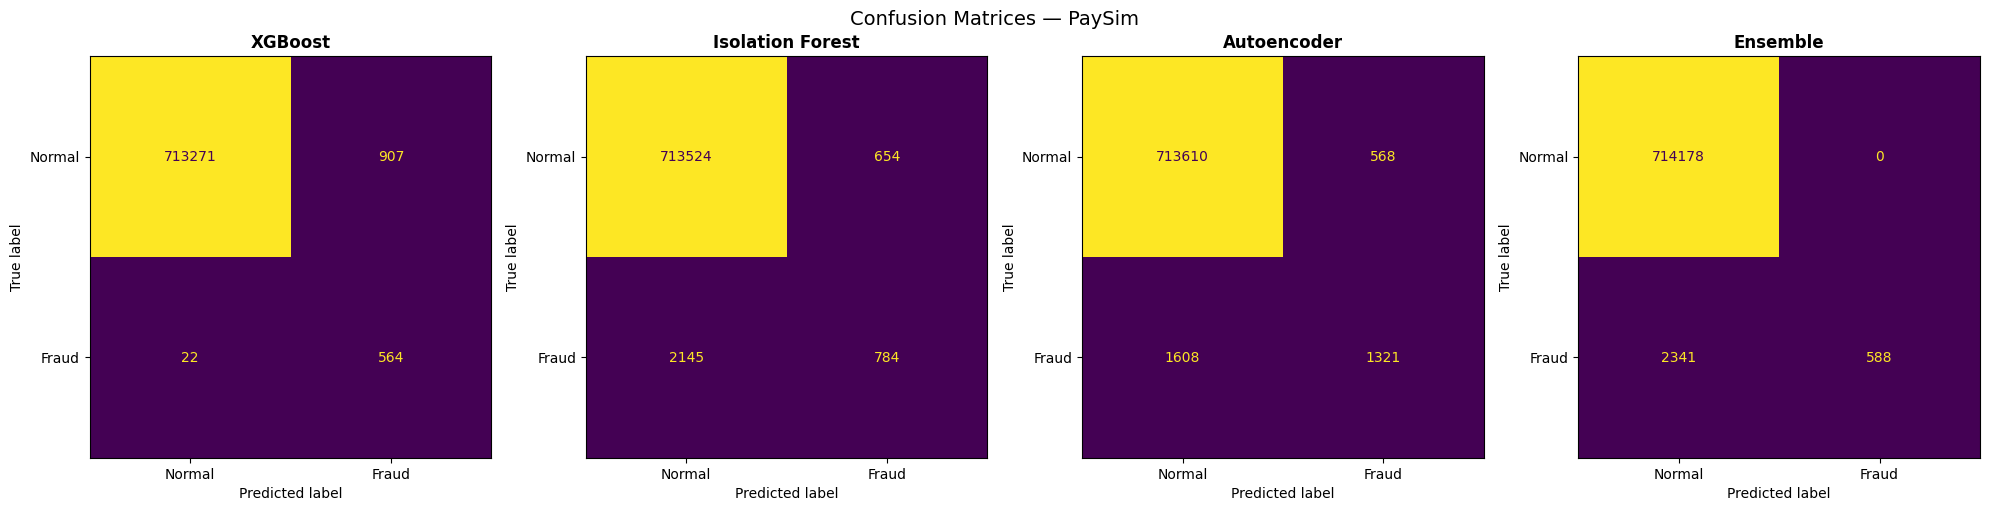

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, model_name in zip(axes, ["XGBoost", "Isolation Forest", "Autoencoder", "Ensemble"]):
    cm   = confusion_matrix(y_test_map[model_name], predictions_dict[model_name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Fraud"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(model_name, fontsize=12, fontweight="bold")
plt.suptitle(f"Confusion Matrices — {DATASET_NAME}", fontsize=14)
plt.tight_layout()
plt.savefig("paysim_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. ROC Curves

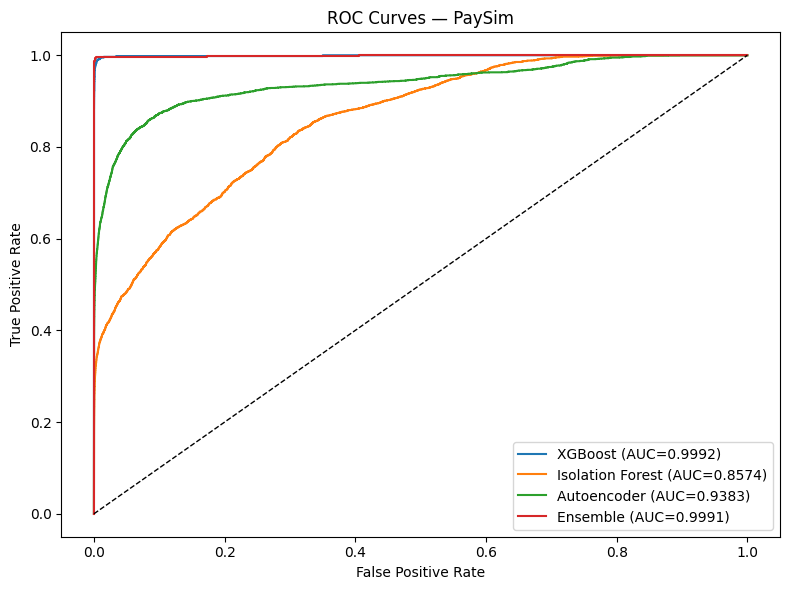

In [18]:
plt.figure(figsize=(8, 6))
for model_name in ["XGBoost", "Isolation Forest", "Autoencoder", "Ensemble"]:
    y_true = y_test_map[model_name]
    fpr, tpr, _ = roc_curve(y_true, scores_dict[model_name])
    auc_val = roc_auc_score(y_true, scores_dict[model_name])
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_val:.4f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves — {DATASET_NAME}")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("paysim_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Precision-Recall Curves

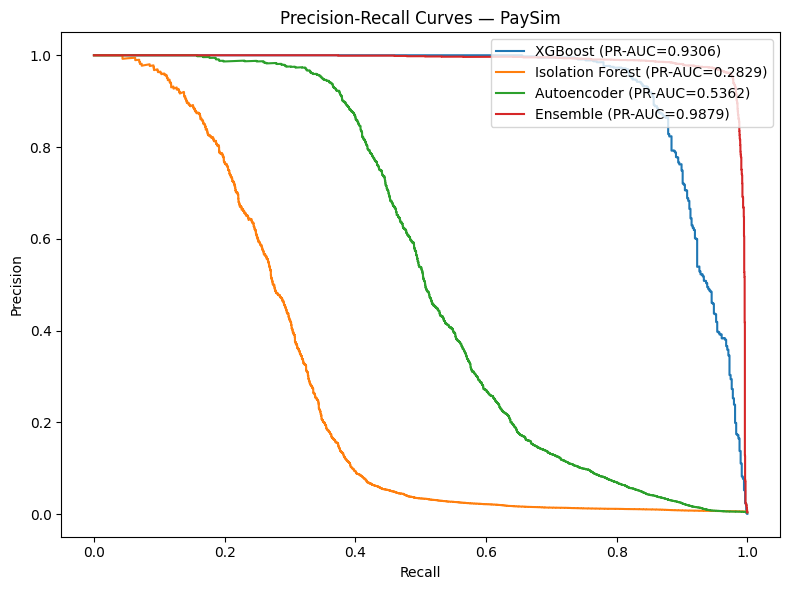

In [19]:
plt.figure(figsize=(8, 6))
for model_name in ["XGBoost", "Isolation Forest", "Autoencoder", "Ensemble"]:
    y_true = y_test_map[model_name]
    prec_vals, rec_vals, _ = precision_recall_curve(y_true, scores_dict[model_name])
    pr_auc_val = average_precision_score(y_true, scores_dict[model_name])
    plt.plot(rec_vals, prec_vals, label=f"{model_name} (PR-AUC={pr_auc_val:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curves — {DATASET_NAME}")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("paysim_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Best Model

In [20]:
best = results_df.sort_values(by="F1-score", ascending=False).iloc[0]
print(f"Best model by F1-score: {best['Model']}")
print(best)

Best model by F1-score: XGBoost
Dataset              PaySim
Model               XGBoost
Precision          0.383413
Recall             0.962457
F1-score           0.548371
ROC-AUC            0.999155
PR-AUC             0.930588
TN                   713271
FP                      907
FN                       22
TP                      564
Train Time (s)    87.631886
Test Time (s)      4.199882
Name: 0, dtype: object


In [22]:
comparison_df = results_df[[
    "Model",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC",
    "PR-AUC"
]].copy()

# сортируем по F1 (главная метрика)
comparison_df = comparison_df.sort_values(by="F1-score", ascending=False)

comparison_df

,Model,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,XGBoost,0.383413,0.962457,0.548371,0.999155,0.930588
2,Autoencoder,0.699312,0.451007,0.548360,0.938345,0.536190
1,Isolation Forest,0.545202,0.267668,0.359057,0.857377,0.282944
3,Ensemble,1.000000,0.200751,0.334376,0.999118,0.987888


## 15. Download Results (Colab)

In [21]:
try:
    from google.colab import files
    for fname in [
        "paysim_final_results.csv",
        "paysim_comparison.csv",
        "paysim_confusion_matrices.png",
        "paysim_roc_curves.png",
        "paysim_pr_curves.png"
    ]:
        files.download(fname)
except ImportError:
    print("Not in Colab — files saved locally.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
comparison_df.to_csv("paysim_final_results.csv", index=False)

In [24]:
from google.colab import files
files.download("paysim_final_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>